<a href="https://colab.research.google.com/github/jerovernay/IMC/blob/main/IMC_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integrantes** \
Reynaldo Martín Peralta Recio, 428/22 \
Jeronimo Vernay, 313/24


# TP I - Trayectorias de Kepler y corrección relativista

Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:
$$
\ddot{u}(θ) + u(θ) - \frac{1}{α} - \delta u²(θ) = 0  
$$
Donde $u(θ) = \frac{1}{r(θ)}$, el Sol se encuentra en el origen, $α$ y $δ$ son constantes. El término con $δ$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f (θ, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

###Solucion:

Para formular el problema como un sistema de orden 1 de la forma $\dot{y} \,=\,f(\theta , y)$, debemos de definir un vector de estado con la variable independiente $θ$, pues la variable independiente deben de ser los angulos.

Sea:

$$\;y_1(\theta) \, = \, u(\theta) \, = \, \frac{1}{r (\theta)} \quad \text{y} \quad y_2(\theta) \, = \, \dot u(\theta) \quad ⇒ \quad y(\theta) \, = \, (y_1(\theta) \,,\, y_2(\theta)) \\[0.3cm]$$

Luego definimos el campo vectorial $\,f(\theta, y)\,$ al derivar sobre $\dot y: \\[0,2cm]$

$$\dot y \, =\, (\dot y_1\, , \, \dot y_2) \,  $$

Donde:

$$ \dot y_1 \, = \, y_2 $$
$$\dot y_2 \, = \, \ddot u \, = \, -u \, + \frac{1}{\alpha} \, \delta \, u^2 $$ $$ \dot y_2 \, = \, -y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2 \\[0,3cm]$$

Por lo tanto:

$$\dot y \, =\, f(\theta, y)\, = \, (\dot y_1 \, , \,\dot y_2) \, = \, (\,y_2 \, , \,-y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2\,) \\[0,3cm]$$

El estado del sistema queda definido por la inversa de la distancia radial ($\,y_1 = u(\theta)$) y su tasa de cambio respecto al ángulo ($y_2 = \dot{u}(\theta)$). Como el ángulo $\theta$ , la variable independiente, no aparece de forma explicita en las ecuaciones, obtenemos un sistema autónomo no lineal de primer orden.

&nbsp;

2. Resolver el problema de Kepler ($δ = 0$), con condiciones iniciales $r(0) = \frac{α}{1 + ϵ}$ y $\dot{r}(0) = 0$. Donde $ϵ$
es la excentricidad de la órbita: $0 ≤ ϵ < 1$ para orbitas cerradas, $ϵ ≥ 1$ para órbitas abiertas. La
condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio
(punto más cercano al Sol). \
Graficar soluciones con $α = 1$ para distintos valores de $ϵ$. Observar que pasa cuando $θ > 2π$ (3 o
4 vueltas).

###Solucion:



<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3231/4155281899.py:59: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(solucion.t, r_res, label=f'Excentricidad $\epsilon={eps}$')
/tmp/ipykernel_3231/4155281899.py:63: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('Trayectorias de Kepler ($\delta=0$) para $\\theta > 2\pi$', va='bottom')


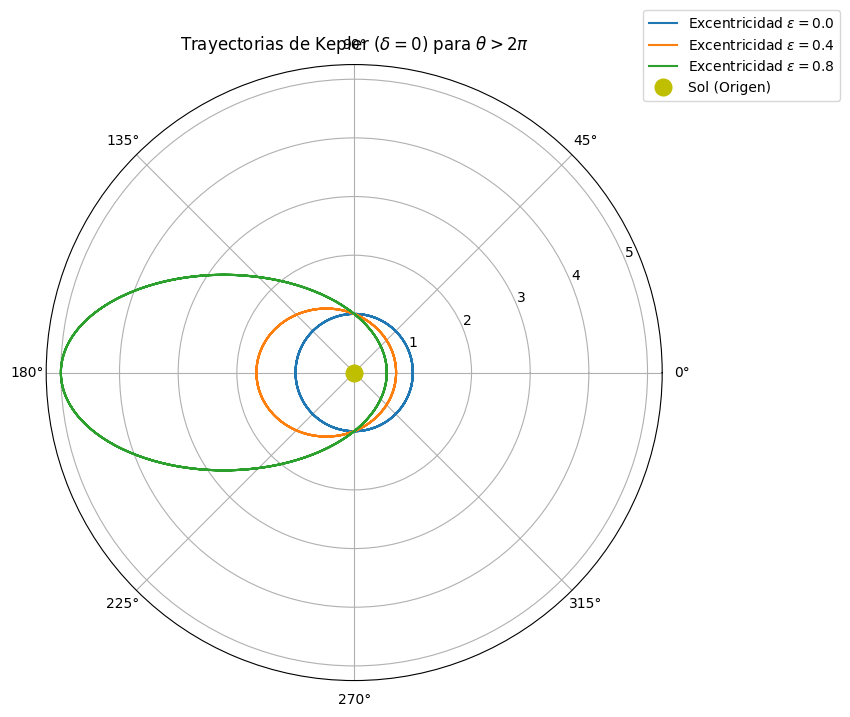

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# 1. Definimos el sistema de ecuaciones de 1er orden (Lo que obtuvimos en el Ej. 1)
def sistema_orbita(theta, y, alpha, delta):
    # Vector de estado y
    u, u_punto = y

    # Ecuaciones del sistema
    du_dtheta = u_punto
    du_punto_dtheta = -u + 1/alpha + delta * (u**2)

    return [du_dtheta, du_punto_dtheta]

# 2. Configuración de parámetros para el ejercicio 2
alpha = 1.0
delta = 0.0

# Vamos a integrar para más de 2*pi para responder la pregunta del enunciado.   ---!!!!---
# 4 vueltas completas = 8 * pi
theta_span = (0, 8 * np.pi)
theta_eval = np.linspace(theta_span[0], theta_span[1], 2000)

# Excentricidades a graficar (órbitas cerradas: 0 <= epsilon < 1)
excentricidades = [0.0, 0.4, 0.8]

# 3. Preparación del gráfico en coordenadas polares
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

for eps in excentricidades:
    # Condiciones iniciales para cada epsilon
    # r(0) = alpha / (1 + eps)  ->  u(0) = (1 + eps) / alpha
    # r_punto(0) = 0              ->  u_punto(0) = 0
    u0 = (1 + eps) / alpha
    u_punto0 = 0
    y0 = [u0, u_punto0]

    # Resolvemos el sistema numéricamente
    solucion = solve_ivp(                   # El que usan en el labo
        fun=sistema_orbita,
        t_span=theta_span,
        y0=y0,
        t_eval=theta_eval,
        args=(alpha, delta),
        method='RK45',      # Runge-Kutta de orden 4(5) es el estándar (lo que mando tincho)
        rtol=1e-8,     # Tolerancia estricta para no perder precisión en varias vueltas
        atol=1e-8       # ???
    )

    # Extraemos 'u' de la solución (primera fila de y)
    u_res = solucion.y[0]

    # Convertimos de nuevo a radio: r = 1 / u
    r_res = 1 / u_res

    # Graficamos
    ax.plot(solucion.t, r_res, label=f'Excentricidad $\epsilon={eps}$')

# Detalles estéticos del gráfico
ax.plot(0, 0, 'yo', markersize=12, label='Sol (Origen)') # El sol en el centro
ax.set_title('Trayectorias de Kepler ($\delta=0$) para $\\theta > 2\pi$', va='bottom')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

3. Resolver el problema relativista para $δ = 0.05$ en las mismas condiciones iniciales del ítem anterior
y comparar. \
El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron
utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.